# Agente con ciclo de razonamiento

Generador de bancos de preguntas técnicas para entrevistas, construido con LangGraph.

Ejecute cada celda en orden. Requiere Ollama local con el modelo `qwen2.5:3b`.

## Modelo de lenguaje y estado compartido

In [1]:
from langchain_ollama import ChatOllama
# temperature = 0.3 keeps responses focused while allowing slight variation.
# Lower values (0.0) make the router too rigid, higher values increase hallucinations

language_model = ChatOllama(model = "qwen2.5:3b", temperature = 0.3)

In [2]:
from typing import TypedDict, Literal
class InterviewerState(TypedDict):
    
    """Shared state for the interview question bank generator agent.

    LangGraph passes this dict to every node and merges each node's return
    value back into it. Fields are grouped by role to make ownership and
    mutation rules explicit:

      Immutable input  — profile: set at graph entry, never written again.
      Dynamic plan     — plan: filled once by plan_node, consumed one item at
                         a time by execute_node. An empty list signals that all
                         areas have been processed and synthesis can begin.
      Accumulated work — completed: grows by one dict per execute_node call
                         via explicit merge (old list + [new_entry]).
      Router decision  — next_action: written by decide_node on every call;
                         the conditional edge reads this field to route the graph.
      Final output     — final_bank: written exactly once by synthesize_node.
      Safety net       — iteration counts decide_node calls; max_iterations
                         caps them to prevent infinite loops on router failure.

    Invariant: a given area name appears in either plan or completed, never both.
    """

    profile: str
    plan: list
    completed: list
    next_action: str
    final_bank: str
    iteration: int
    max_iterations: int

## Nodos de trabajo: plan, execute y synthesize

In [3]:
from langchain_core.prompts import ChatPromptTemplate
# One-area-per-line format is deliberately simple: it lets splitlines() do the
# parsing without a schema. with_structured_output() would be more robust but
# adds overhead that is unnecessary for a flat string list.

planner_prompt = ChatPromptTemplate.from_template(
    """You are a senior technical recruiter. Given a candidate profile, generate a list
of 4 to 5 technical areas to evaluate in an interview.

Profile: {profile}

Output rules:
- ONE area per line
- No numbering, no bullets, no dashes
- No extra text before or after
- Each area must be a short name (2-5 words)

Areas to evaluate:"""
)

In [4]:
def plan_node(state: InterviewerState) -> dict:

    """Generate the initial list of technical areas to cover in the interview.

    Runs exactly once per agent execution. decide_node's correction block
    prevents routing here again once state["plan"] is non-empty, even if the
    LLM suggests "plan" a second time.

    Args:
        state: Current agent state. Reads 'profile'.

    Returns:
        {"plan": list[str]} with one entry per technical area to evaluate.
    """

    chain = planner_prompt | language_model
    response = chain.invoke({"profile": state["profile"]})

    # Filter blank lines that appear when the model adds trailing newlines
    areas = [line.strip() for line in response.content.splitlines() if line.strip()]

    print(f"   [plan] Generated {len(areas)} areas: {areas}")
    return {"plan": areas}

In [5]:
executor_prompt = ChatPromptTemplate.from_template(
    """You are a senior technical interviewer. Generate EXACTLY 2 questions to evaluate
the candidate in the given area: one intermediate-level and one advanced-level.

Candidate profile: {profile}
Area to evaluate: {area}

Output rules:
- ONE question per line
- No numbering, no bullets
- No extra text before or after

Questions:"""
)

In [6]:
def execute_node(state: InterviewerState) -> dict:

    """Generate two interview questions for the next pending area and move it to completed.

    Takes the first item from state["plan"] (FIFO order), invokes the LLM for
    questions, then returns the updated plan and completed lists.

    Accumulation via explicit merge:
        LangGraph replaces each field with whatever the node returns, so to
        accumulate results the node must return the full new list, not just the
        new element. The pattern is: read current list → build new list → return.
        This never mutates 'state' in place, which would corrupt shared state.

    Args:
        state: Current agent state. Reads 'profile', 'plan', 'completed'.

    Returns:
        {"plan": remaining areas, "completed": all completed areas + new entry},
        or {} if plan was unexpectedly empty (defensive guard against bad routing).
    """
    
    # Guard: decide_node should never route here with an empty plan, but a
    # hallucinated router response could. Returning {} leaves state unchanged.
    if not state["plan"]:
        return {}

    current_area = state["plan"][0]

    chain = executor_prompt | language_model
    response = chain.invoke({"profile": state["profile"], "area": current_area})

    questions = [line.strip() for line in response.content.splitlines() if line.strip()]
    new_entry = {"area": current_area, "questions": questions}

    print(f"   [execute] Area '{current_area}' done — {len(questions)} questions")

    return {
        "plan": state["plan"][1:],                         # remove processed head
        "completed": state["completed"] + [new_entry]      # explicit merge
    }

In [7]:
def synthesize_node(state: InterviewerState) -> dict:

    """Compile every completed area into a single formatted Markdown question bank.

    No LLM call is made here — the output format is fully deterministic, so
    using a model would add latency and nondeterminism with no benefit.

    This node is wired to a fixed edge pointing directly to END (not back to
    decide_node), because once the bank is generated there are no further
    decisions to make.

    Args:
        state: Current agent state. Reads 'profile' and 'completed'.

    Returns:
        {"final_bank": str} — complete Markdown document ready to display or export.
    """
    
    sections = [f"# Interview Question Bank: {state['profile']}\n"]

    for i, entry in enumerate(state["completed"], 1):
        sections.append(f"## {i}. {entry['area']}\n")
        for j, question in enumerate(entry["questions"], 1):
            sections.append(f"{j}. {question}")
        sections.append("")  # blank line between sections

    final_bank = "\n".join(sections)

    print(f"   [synthesize] Bank compiled — {len(state['completed'])} areas")
    return {"final_bank": final_bank}

## El nodo de decisión y el enrutamiento

In [8]:
router_prompt = ChatPromptTemplate.from_template(
    """You are the decision engine of an interview question generator agent.
Select the NEXT action by applying these rules in order — stop at the first match:

1. If "Final bank generated" is yes                               -> done
2. If "Pending areas" is NOT (empty)                             -> execute
3. If "Pending areas" is (empty) AND "Completed areas" is NOT [] -> synthesize
4. If "Pending areas" is (empty) AND "Completed areas" is []     -> plan

Current state:
{state_summary}

Reply with ONLY one word: plan, execute, synthesize, or done"""
)

# List (not set) because next() iterates in insertion order.
# "done" is last so it only wins when none of the work actions appear in the response.
VALID_ACTIONS = ["plan", "execute", "synthesize", "done"]

In [9]:
def _build_state_summary(state: InterviewerState) -> str:

    """Serialize the relevant parts of the state into a short human-readable string.

    Kept as a separate function so it can be tested in isolation and so
    decide_node stays readable. The summary text is injected directly into the
    router prompt, so its wording directly influences routing quality.

    Args:
        state: Current agent state.

    Returns:
        Multi-line string with pending work, progress, and iteration count.
    """

    return (
        f"- Profile: {state['profile']}\n"
        f"- Pending areas: {state['plan'] if state['plan'] else '(empty)'}\n"
        f"- Completed areas: {[e['area'] for e in state['completed']]}\n"
        f"- Final bank generated: {'yes' if state['final_bank'] else 'no'}\n"
        f"- Iteration: {state['iteration']} of {state['max_iterations']}"
    )

In [10]:
def decide_node(state: InterviewerState) -> dict:

    """Router node: increment the iteration counter, then ask the LLM what to do next.

    Implements the two-step router pattern:
      1. This node writes state["next_action"] with the chosen action string.
      2. The conditional edge function route_by_decision reads that field and
         returns it — the edge itself contains no logic.

    Persisting the decision in state (rather than returning it only as an edge
    label) makes each routing choice observable via stream_mode="values".

    The safety net fires before the LLM call to avoid a wasted invocation.
    It prefers "synthesize" over "done" when work is partially complete so the
    agent produces a useful partial result rather than terminating abruptly.

    After the LLM responds, a correction block overrides decisions that conflict
    with the observable state. This handles the two most common failure modes of
    small models: re-planning when a plan already exists, and failing to switch
    to "synthesize" when the plan is exhausted.

    Args:
        state: Current agent state. All fields are read to build the summary.

    Returns:
        {"next_action": str, "iteration": int}
    """

    new_iteration = state["iteration"] + 1

    # Safety net: force an orderly exit when iteration budget is exhausted.
    # Prefer synthesize so partial work is not lost.
    if new_iteration > state["max_iterations"]:
        forced = "synthesize" if state["completed"] and not state["final_bank"] else "done"
        print(f"   [decide] SAFETY NET triggered -> {forced}")
        return {"next_action": forced, "iteration": new_iteration}

    chain = router_prompt | language_model
    response = chain.invoke({"state_summary": _build_state_summary(state)})
    raw = response.content.strip().lower()

    # Fuzzy match: accept the first valid action word found in the response.
    # Falls back to "done" if no known action appears, which terminates safely.
    action = next((a for a in VALID_ACTIONS if a in raw), "done")

    # Post-LLM correction: override when the decision conflicts with the observable state.
    # Guards against the two failure modes observed with small models on this prompt:
    #   1. Choosing "plan" when a plan already exists (causes plan overwrite and duplicate areas).
    #   2. Choosing "plan" or "execute" when the plan is exhausted (should synthesize instead).
    if state["final_bank"]:
        action = "done"
    elif state["plan"] and action == "plan":
        # Plan already exists — execute the next pending area, don't overwrite the plan.
        action = "execute"
    elif not state["plan"] and state["completed"] and action not in ("synthesize", "done"):
        # All areas processed — compile the bank regardless of what the LLM said.
        action = "synthesize"

    print(f"   [decide] iter={new_iteration}  action={action}")
    return {"next_action": action, "iteration": new_iteration}

In [11]:
def route_by_decision(state: InterviewerState) -> Literal["plan", "execute", "synthesize", "done"]:

    """Conditional edge function that reads the decision already written by decide_node.

    Intentionally trivial: all routing logic lives in decide_node, not here.
    Separating the two responsibilities means the routing decision is persisted
    in state (auditable after execution) and decide_node is independently
    testable without compiling the full graph.

    Args:
        state: Current agent state. Reads 'next_action'.

    Returns:
        The action string written by decide_node, matched to graph node names.
    """
    
    return state["next_action"]

## Construcción y visualización del grafo

In [12]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
agent_graph = StateGraph(InterviewerState)

# Register all four nodes
agent_graph.add_node("decide", decide_node)
agent_graph.add_node("plan", plan_node)
agent_graph.add_node("execute", execute_node)
agent_graph.add_node("synthesize", synthesize_node)

# The graph always enters through decide so the router drives the first action
agent_graph.add_edge(START, "decide")

# Conditional edges from the router: action name == node name in this graph,
# but the explicit mapping makes the routing contract visible and allows
# renaming nodes without changing VALID_ACTIONS.
agent_graph.add_conditional_edges(
    "decide",
    route_by_decision,
    {
        "plan": "plan",
        "execute": "execute",
        "synthesize": "synthesize",
        "done": END,
    }
)

# Action nodes cycle back to decide — the router decides what to do after each one
agent_graph.add_edge("plan", "decide")
agent_graph.add_edge("execute", "decide")

# synthesize exits directly: once the bank is written there is nothing left to decide
agent_graph.add_edge("synthesize", END)

agent_app = agent_graph.compile()

print("Agent compiled successfully\n")

Agent compiled successfully



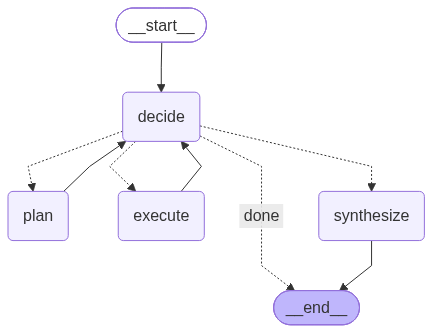

In [13]:
# PNG via the Mermaid online renderer (requires internet access)
try:
    display(Image(agent_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render PNG ({e})")
    agent_app.get_graph().print_ascii()

## Ejecución del agente

In [14]:
# All list and string fields start empty; the agent fills them during execution.
# max_iterations=15 is a generous budget: plan(1) + execute(4-5) + decide calls
# typically total 10-12 steps for a 4-5 area profile.
initial_state = {
    "profile": "Senior Backend Developer in Python with experience in distributed systems and AWS",
    "plan": [],
    "completed": [],
    "next_action": "",
    "final_bank": "",
    "iteration": 0,
    "max_iterations": 15
}

### Modo 1: stream por eventos (delta por nodo)

In [15]:
print("=" * 70)
print("AGENT EXECUTION — EVENT STREAM")
print("=" * 70)

# Default stream() mode: emits one event per node execution, where each event
# is {node_name: partial_state_update}. Useful for auditing what each node wrote.
events = []
for event in agent_app.stream(initial_state):
    for node_name, update in event.items():
        events.append((node_name, update))

print(f"\nTotal steps executed: {len(events)}")

AGENT EXECUTION — EVENT STREAM
   [decide] iter=1  action=plan
   [plan] Generated 5 areas: ['Distributed Systems', 'AWS Services', 'Database Management', 'Microservices Architecture', 'API Design']
   [decide] iter=2  action=execute
   [execute] Area 'Distributed Systems' done — 2 questions
   [decide] iter=3  action=execute
   [execute] Area 'AWS Services' done — 2 questions
   [decide] iter=4  action=execute
   [execute] Area 'Database Management' done — 2 questions
   [decide] iter=5  action=execute
   [execute] Area 'Microservices Architecture' done — 2 questions
   [decide] iter=6  action=execute
   [execute] Area 'API Design' done — 2 questions
   [decide] iter=7  action=synthesize
   [synthesize] Bank compiled — 5 areas

Total steps executed: 14


### Modo 2: stream_mode="values" (estado completo por paso)

In [16]:
# stream_mode="values" emits the FULL state after each node, not just the delta.
# This makes the accumulation pattern visible: watch plan shrink and completed grow.
print("State evolution per step:\n")

last_snapshot = None
for i, snapshot in enumerate(agent_app.stream(initial_state, stream_mode = "values")):
    last_snapshot = snapshot
    bank_repr = "(empty)" if not snapshot["final_bank"] else f"{len(snapshot['final_bank'])} chars"
    completed_areas = [e["area"] for e in snapshot["completed"]]

    print(f"--- Snapshot {i} ---")
    print(f"  iteration   = {snapshot['iteration']}")
    print(f"  next_action = {snapshot['next_action']!r}")
    print(f"  plan        = {snapshot['plan']}")
    print(f"  completed   = {completed_areas}")
    print(f"  final_bank  = {bank_repr}")
    print()

State evolution per step:

--- Snapshot 0 ---
  iteration   = 0
  next_action = ''
  plan        = []
  completed   = []
  final_bank  = (empty)

   [decide] iter=1  action=plan
--- Snapshot 1 ---
  iteration   = 1
  next_action = 'plan'
  plan        = []
  completed   = []
  final_bank  = (empty)

   [plan] Generated 5 areas: ['Distributed Systems', 'AWS Services', 'Database Management', 'Microservices', 'API Design']
--- Snapshot 2 ---
  iteration   = 1
  next_action = 'plan'
  plan        = ['Distributed Systems', 'AWS Services', 'Database Management', 'Microservices', 'API Design']
  completed   = []
  final_bank  = (empty)

   [decide] iter=2  action=execute
--- Snapshot 3 ---
  iteration   = 2
  next_action = 'execute'
  plan        = ['Distributed Systems', 'AWS Services', 'Database Management', 'Microservices', 'API Design']
  completed   = []
  final_bank  = (empty)

   [execute] Area 'Distributed Systems' done — 2 questions
--- Snapshot 4 ---
  iteration   = 2
  next_action 

### El banco de preguntas generado

In [17]:
print("=" * 70)
print("FINAL QUESTION BANK")
print("=" * 70)
print(last_snapshot["final_bank"])

FINAL QUESTION BANK
# Interview Question Bank: Senior Backend Developer in Python with experience in distributed systems and AWS

## 1. Distributed Systems

1. How would you design a system to handle failures in a distributed environment where data consistency is crucial, and explain the trade-offs you would consider in your design?
2. Given a complex, distributed system that spans multiple AWS regions, how would you ensure that data is replicated and updated correctly across all nodes, while also maintaining high availability and low latency for users? Consider the challenges and potential solutions you would implement.

## 2. AWS Services

1. What are the key differences between using Amazon S3 for object storage and Amazon S3 for database storage? How would you design a system to handle high-throughput read and write operations using S3, and what AWS services would you integrate to achieve this?
2. How would you design a highly available and scalable AWS architecture for a real-time